# Simulation Study

Five experiments, each isolating one claim about MoLA's archetype recovery:

1. **Archetype Recovery** — does MoLA recover the generating structure at all?
2. **Estimation Stability** — does the solution depend on arbitrary initialization? If estimation is stable, we expect essentially equivalent estimates despite different starting points.
3. **Robustness to Data Sparsity** — how gracefully does archetype recovery deteriorate as the information available for estimating the latent structure decreases (number of users, number of item responses per user)?
4. **Sensitivity to the Number of Archetypes** — what happens when the fitted number of archetypes $M$ is misspecified relative to the true generating count?
5. **Computational Scalability** — how does fit time grow with problem size?

Each needs a different axis held fixed and a different axis varied, which is why these are five separate experiments rather than one combined sweep.

Out of scope: do the learned latent variables correspond to real cognitive mastery or useful learner groups? → simulation cannot establish this; you need empirical/external validation.

In [27]:
%load_ext autoreload
%autoreload 2

In [1]:
# Allows import of modules from src/ in root
%cd ..

/Users/marialentini/Projects/mixture-of-latent-archetypes


/Users/marialentini/Projects/mixture-of-latent-archetypes/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# Publication styling for every figure below (src/style.py): fonts/line
# weights sized for print rather than a monitor, vector-safe embedded text,
# no LaTeX toolchain dependency. figsize(...) below sizes each figure to an
# exact fraction of an ACM acmart (\documentclass[sigconf]{acmart}) column or
# text width in points -- swap the "acm-sigconf-*" keys (or pass a raw point
# value) if this paper uses a different document class; see src/style.py for
# how to read the exact number off your own compiled .log file.
from src.style import apply, figsize

apply()

## 1. Archetype Recovery

Fit MoLA on one well-specified condition and compare the recovered archetype profiles to the ones that generated the data, after Hungarian alignment.

{'mu_rmse': 0.12914139331163255, 'assignment_ari': 0.46649375154623046, 'holdout_auc': 0.7418960988779331}


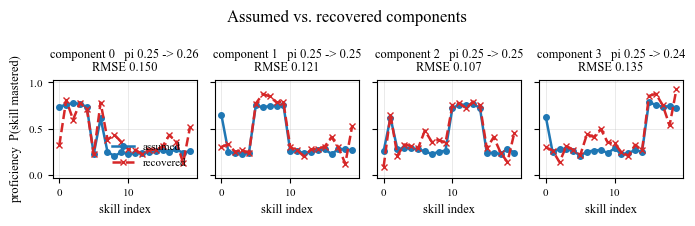

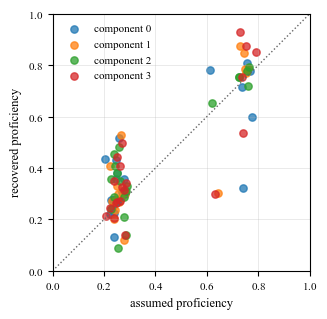

In [3]:
import matplotlib.pyplot as plt
from src.simulations import run_condition
from src.simulations.factors import SimulationCondition
from src.simulations.viz import plot_component_recovery, plot_recovery_scatter

result = run_condition(SimulationCondition(n_archetypes=4, n_learners=10_000), seed=0, return_fit=True)
plot_component_recovery(
    result, 
    figsize=figsize("acm-sigconf-text", aspect=0.32), 
    save="figures/component_recovery.pdf"
)

# plot_recovery_scatter has no figsize= of its own -- pass a pre-sized ax instead.
_, scatter_ax = plt.subplots(figsize=figsize("acm-sigconf-column", aspect=1.0))
plot_recovery_scatter(result, ax=scatter_ax, save="figures/recovery_scatter.pdf")

print({k: result.metrics[k] for k in ("mu_rmse", "assignment_ari", "holdout_auc")})

## 2. Estimation Stability

Fix one simulated dataset and its train/holdout split, then re-fit it many times, varying only the EM initialization draw (`run_init_repeats`). Every recovered archetype is aligned back to the true ones independently each time, then plotted together to show the spread across initializations -- tight bundles argue the solution doesn't depend on where EM started.

mean    0.115762
std     0.024929
min     0.088945
max     0.222740
dtype: float64

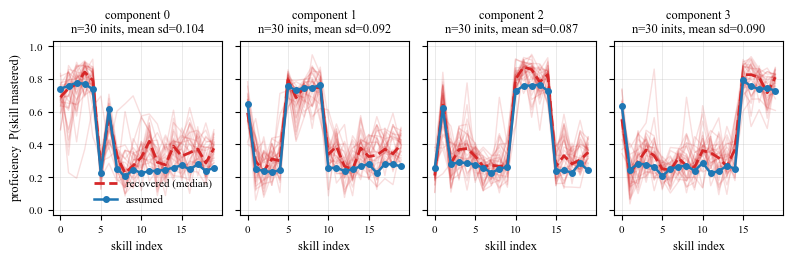

In [ ]:
import pandas as pd
from src.simulations.factors import SimulationCondition
from src.simulations.run import run_init_repeats
from src.simulations.viz import plot_component_recovery_distribution

stability_condition = SimulationCondition(
    n_archetypes=4, 
    n_learners=10_000, 
    initialization="random", 
    responses_per_learner=30,
    n_items=1000
)
stability_results = run_init_repeats(stability_condition, data_seed=0, n_repeats=30)
plot_component_recovery_distribution(
    stability_results, 
    figsize=(8, 2.7),
    save="figures/stability.pdf"
)

mu_rmse_by_repeat = pd.Series([r.metrics["mu_rmse"] for r in stability_results])
mu_rmse_by_repeat.describe()[["mean", "std", "min", "max"]]

## 3. Robustness to Data Sparsity

One-factor-at-a-time sweep over the two evidence factors named in the claim -- number of users (`n_learners`) and number of item responses per user (`responses_per_learner`) -- holding everything else at baseline. `plot_ofat_sensitivity` takes the raw per-run table from `run_design` directly (not `summarize_results`'s aggregated output, which drops the per-condition factor columns this needs) and computes the mean/std per level itself.

A full OFAT grid at higher replication counts is many fits -- this starts small (`n_replications=5`, few levels); widen before using the figure for the final write-up.

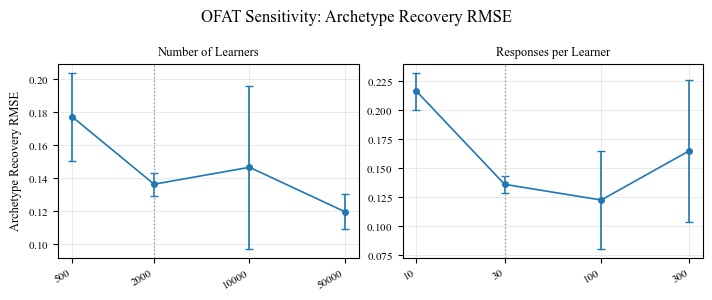

In [5]:
from src.simulations.factors import ofat_design
from src.simulations.run import run_design
from src.simulations.viz import plot_ofat_sensitivity

sparsity_factors = ["n_learners", "responses_per_learner"]
sparsity_conditions = ofat_design(factors=sparsity_factors)
sparsity_results = run_design(sparsity_conditions, n_replications=6, base_seed=0)

fig = plot_ofat_sensitivity(
    sparsity_results,
    factors=sparsity_factors,
    metric="mu_rmse",
    log_x=True,
    save="figures/sparsity.pdf",
)

## 4. Sensitivity to the Number of Archetypes

Fit the SAME simulated data (`run_m_sweep` holds the data and train/holdout split fixed, since neither depends on `n_components_fit`) with a range of fitted archetype counts around the true one. `initialization="random"` is required here -- k-means/informed init assume the correct number of archetypes and `_initial_params` raises if they're combined with a misspecified `n_components_fit`.

`effective_n_archetypes()` -- the participation ratio of the fitted `mu` -- should saturate near the true count even once the model is handed more components than it needs, which is the payoff of the archetype-redundancy diagnostics built onto `MoLA` (`effective_n_archetypes`, `redundancy_report`).

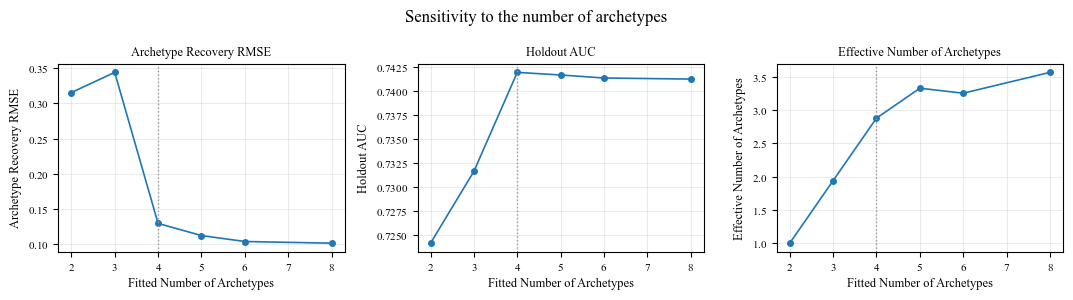

In [6]:
from src.simulations.factors import SimulationCondition
from src.simulations.run import run_m_sweep
from src.simulations.viz import plot_m_sensitivity

true_n_archetypes = 4
m_condition = SimulationCondition(n_archetypes=true_n_archetypes, n_learners=10_000)
m_results = run_m_sweep(m_condition, n_components_grid=[2, 3, 4, 5, 6, 8], seed=0)

fig = plot_m_sensitivity(
    m_results,
    true_n_archetypes=true_n_archetypes,
    metrics=("mu_rmse", "holdout_auc", "effective_n_archetypes"),
    save="figures/m_sensitivity.pdf",
)

## 5. Computational Scalability

Wall-clock fit time (`train_time_sec`, recorded by every `run_condition` call already) as problem size grows, using the same OFAT machinery as Section 3 but over the factors that plausibly drive compute cost: number of users, number of skills, and number of archetypes.

Plotted log-log (`log_x=True, log_y=True`): a power-law cost `time ~ n^p` is a straight line of slope `p` on log-log axes, so this is the honest way to read off the scaling exponent. Plotted with a linear time axis instead, genuinely linear cost (`p=1`) bends upward and can look quadratic or exponential -- a straight line under log-x/linear-y actually corresponds to *logarithmic* growth, not linear.

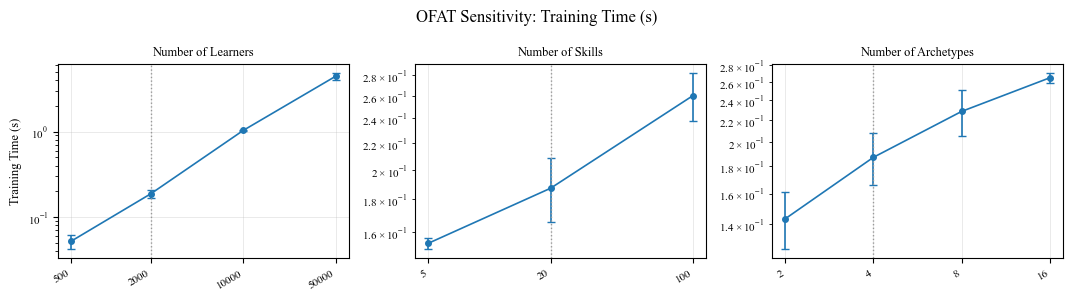

In [7]:
from src.simulations.factors import ofat_design
from src.simulations.run import run_design
from src.simulations.viz import plot_ofat_sensitivity

scalability_factors = ["n_learners", "n_skills", "n_archetypes"]
scalability_conditions = ofat_design(factors=scalability_factors)
scalability_results = run_design(scalability_conditions, n_replications=3, base_seed=0)

# log-log: a power law reads as a straight line whose slope is the exponent.
# (log_x alone, with a linear time axis, makes genuinely linear cost bend
# upward and look quadratic/exponential -- see the discussion above.)
fig = plot_ofat_sensitivity(
    scalability_results,
    factors=scalability_factors,
    metric="train_time_sec",
    log_x=True,
    log_y=True,
    save="figures/scalability.pdf",
)